In [1]:
import os
import struct
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import torch.optim.lr_scheduler as lr_scheduler
import time
import csv
import glob
from diffraction_utils import load_experimental_data
from load_xml_phases import *
import torch.nn.functional as F
import matplotlib.pyplot as plt
import pandas as pd
import gc

In [2]:
difr_dir = "../../nn_data_2.5/"
Data_name = "s2.5"
os.makedirs(difr_dir, exist_ok=True)

# Автовыбор вычислительного устройства
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print('device =', device)

# Вычисляем размер входа для свертки
input_size = 4001
num_phases = 12

xml_name = 'OSO'
model_ver = 'light_3'
wghts_fname = f'weights3_{xml_name}_{model_ver}.pth'
#csv_res_fname = f"{xml_name}_{model_ver}.csv"

inp_data = []
out_data = []

PHASES_INFO = []

experiment_folder = 'XY_OSO_midKO'

device = cuda:0


In [3]:
# Создаем словарь для сопоставления имен файлов и целевых значений
target_values = {
    'Бо1125_180121.xy': np.array([0.42, 0.25, 42.72, 44.65, 2.22, 8.05, 0.00, 1.40, 0.28, 0.00, 0.01, 0.00]),
    'Бо2074_200121.xy': np.array([0.50, 0.24, 58.48, 27.85, 2.88, 7.90, 0.05, 1.62, 0.48, 0.00, 0.01, 0.00]),
    'Бо2077_200121.xy': np.array([0.40, 0.93, 67.24, 18.25, 3.63, 7.51, 0.03, 1.60, 0.42, 0.00, 0.00, 0.00]),
    'Бр1026_181220.xy': np.array([2.72, 2.78, 47.84, 28.73, 1.20, 14.57, 0.07, 2.06, 0.03, 0.00, 0.00, 0.00]),
    'Бр1071_241220.xy': np.array([1.22, 0.63, 50.30, 30.39, 1.60, 13.97, 0.06, 1.84, 0.00, 0.00, 0.00, 0.00]),
    'Бр1307_2_181220.xy': np.array([0.68, 1.17, 86.07, 0.94, 3.65, 1.29, 4.55, 0.31, 0.79, 0.05, 0.52, 0.00]),
    'Бр1356_251220.xy': np.array([1.67, 2.21, 78.72, 2.34, 7.51, 3.22, 2.43, 1.09, 0.51, 0.28, 0.02, 0.00]),
    'Бр1425_241220.xy': np.array([0.90, 1.56, 81.95, 1.43, 6.32, 2.76, 3.40, 0.85, 0.68, 0.16, 0.00, 0.00]),
    'Бр1428_241220.xy': np.array([1.07, 2.47, 63.14, 15.82, 0.80, 14.47, 0.66, 1.58, 0.00, 0.00, 0.00, 0.00]),
    'Бр1566_281220.xy': np.array([0.72, 3.95, 70.88, 5.65, 6.65, 9.87, 0.12, 2.14, 0.00, 0.00, 0.01, 0.00]),
    'В506_140121.xy': np.array([2.11, 2.59, 54.29, 21.35, 2.26, 15.51, 0.06, 1.59, 0.24, 0.00, 0.01, 0.00]),
    'В508_140121.xy': np.array([2.12, 3.48, 48.43, 27.17, 1.62, 15.24, 0.05, 1.63, 0.26, 0.00, 0.01, 0.00]),
    'В549_150121.xy': np.array([1.01, 3.74, 78.07, 0.43, 13.37, 0.44, 1.63, 0.24, 0.17, 0.00, 0.89, 0.00]),
    'В574_150121.xy': np.array([0.52, 1.16, 52.24, 24.86, 1.70, 16.05, 0.03, 3.32, 0.11, 0.00, 0.00, 0.00]),
    'В583_180121.xy': np.array([0.45, 1.25, 52.71, 24.86, 2.10, 16.14, 0.06, 2.38, 0.04, 0.00, 0.01, 0.00]),
    'И103_291220.xy': np.array([1.02, 3.74, 53.23, 30.05, 1.25, 5.35, 4.20, 1.05, 0.00, 0.11, 0.00, 0.00]),
    'И128_120121.xy': np.array([1.16, 3.16, 59.49, 23.44, 1.06, 7.46, 2.84, 1.33, 0.00, 0.06, 0.00, 0.00]),
    'И538_110121.xy': np.array([1.42, 0.97, 72.78, 9.48, 2.78, 10.23, 0.42, 1.19, 0.00, 0.72, 0.00, 0.00]),
    'И644_110121.xy': np.array([1.24, 4.00, 73.64, 6.08, 7.94, 4.33, 1.11, 0.93, 0.00, 0.63, 0.00, 0.00]),
    'И743_211220.xy': np.array([0.39, 1.37, 88.97, 0.92, 2.73, 0.32, 4.03, 0.12, 0.42, 0.28, 0.44, 0.00]),
    'И9085_130121.xy': np.array([0.48, 0.14, 42.95, 44.21, 1.04, 10.34, 0.07, 0.71, 0.06, 0.00, 0.00, 0.00]),
    'К173_210121.xy': np.array([0.68, 2.13, 45.16, 36.51, 1.06, 10.94, 0.07, 2.73, 0.29, 0.43, 0.00, 0.00]),
    'К1898_270121.xy': np.array([1.89, 1.83, 55.79, 17.94, 2.05, 13.11, 0.43, 2.62, 0.14, 4.21, 0.00, 0.00]),
    'К2019_270121.xy': np.array([1.30, 3.43, 67.70, 7.81, 2.77, 10.36, 0.05, 2.19, 0.40, 4.00, 0.00, 0.00]),
    'К2022_280121.xy': np.array([1.18, 1.49, 58.94, 15.68, 2.12, 13.57, 0.08, 2.58, 0.46, 3.91, 0.00, 0.00]),
    'К2035_280121.xy': np.array([0.99, 1.88, 57.56, 16.03, 2.68, 12.59, 0.11, 2.36, 0.43, 5.37, 0.00, 0.00]),
    'К2041_280121.xy': np.array([0.95, 2.44, 49.16, 25.80, 1.25, 13.73, 0.07, 2.76, 0.22, 3.62, 0.00, 0.00]),
    'К2042_290121.xy': np.array([0.87, 0.92, 83.39, 0.71, 0.34, 0.11, 6.30, 0.00, 0.24, 4.62, 2.51, 0.00]),
    'С152_161220.xy': np.array([0.26, 1.65, 33.93, 52.38, 0.73, 9.34, 0.27, 0.99, 0.04, 0.38, 0.04, 0.00]),
    'С207_181220.xy': np.array([0.32, 0.61, 42.08, 44.57, 0.83, 9.56, 0.29, 1.31, 0.00, 0.42, 0.00, 0.00]),
    'С294_211220.xy': np.array([0.77, 2.01, 57.04, 26.08, 2.25, 8.96, 0.34, 1.74, 0.00, 0.83, 0.00, 0.00]),
    'С343_221220.xy': np.array([1.84, 1.80, 51.13, 33.75, 1.11, 7.74, 0.75, 1.31, 0.00, 0.56, 0.00, 0.00]),
    'С367_231220.xy': np.array([0.47, 1.94, 56.72, 26.99, 1.58, 9.51, 0.39, 1.60, 0.00, 0.81, 0.00, 0.00]),
    'С455_171220.xy': np.array([0.20, 2.09, 32.42, 53.03, 0.80, 9.33, 0.46, 1.01, 0.00, 0.28, 0.38, 0.00]),
    'С479_231220.xy': np.array([0.73, 1.32, 53.55, 31.52, 1.41, 9.09, 0.29, 1.45, 0.00, 0.63, 0.00, 0.00]),
    'С490_231220.xy': np.array([1.05, 2.49, 55.01, 30.80, 1.07, 4.45, 3.10, 1.48, 0.01, 0.55, 0.00, 0.00]),
    'дБо2058д_240521.xy': np.array([0.00, 0.74, 10.33, 59.61, 2.16, 5.09, 0.13, 21.81, 0.15, 0.00, 0.00, 0.00]),
    'дБо2082д_280521.xy': np.array([0.62, 0.35, 85.91, 0.00, 0.00, 0.00, 3.22, 0.00, 9.42, 0.06, 0.17, 0.00]),
    'дБр1307д_220421.xy': np.array([0.93, 0.36, 85.71, 0.39, 0.35, 0.03, 9.36, 0.00, 0.24, 0.00, 1.22, 1.43]),
    'дБр1552д_020621.xy': np.array([0.89, 0.00, 85.48, 0.25, 0.34, 0.00, 6.05, 0.03, 0.58, 0.00, 0.37, 6.00]),
    'дК1132д_180521.xy': np.array([2.42, 1.47, 75.98, 0.48, 0.61, 0.17, 9.58, 0.06, 4.70, 0.16, 2.08, 2.28]),
    'дК1585д_170521.xy': np.array([0.43, 1.17, 84.69, 0.00, 0.00, 0.00, 9.71, 0.00, 1.83, 1.65, 0.46, 0.00]),
    'дК180д_290421.xy': np.array([0.19, 1.93, 26.94, 42.17, 4.99, 17.44, 0.06, 5.90, 0.00, 0.40, 0.00, 0.00]),
    'дС132д_210421.xy': np.array([0.29, 2.38, 26.13, 41.49, 2.17, 16.56, 0.10, 10.58, 0.27, 0.03, 0.00, 0.00]),
    'дС321д_120521.xy': np.array([0.42, 1.90, 20.31, 38.45, 3.73, 20.36, 0.10, 14.56, 0.00, 0.02, 0.16, 0.00]),
    'дС323д_170521.xy': np.array([0.17, 1.65, 21.48, 30.25, 7.69, 19.54, 0.03, 18.75, 0.14, 0.07, 0.24, 0.00])
}

In [4]:
# Функция для расчёта криолитового отношения (КО)
def compute_cr(values):
    """
    Принимает массив из 12 чисел (в порядке headers) и возвращает КО.
    """
    # Извлекаем нужные компоненты по индексам
    Cry = values[2]      # 2
    Chi = values[3]      # 3
    CaCry1 = values[4]   # 4
    CaCry1_5 = values[5] # 5
    Web = values[7]      # 7
    Neib = values[8]     # 8
    Elpas = values[9]    # 9
    NaF = values[11]     # 11

    numerator = 2 * (0.6 * Cry + 0.4545 * Chi + 0.1727 * CaCry1_5 + 0.2058 * CaCry1 + 0.3647 * Web + 0.4026 * Neib + 0.1734 * Elpas + NaF)

    denominator = (0.4 * Cry + 0.5455 * Chi + 0.3454 * CaCry1_5 + 0.4116 * CaCry1 + 0.3647 * Web + 0.3468 * Elpas)

    if denominator == 0:
        return float('inf')  # или другое значение по умолчанию
    return numerator / denominator

def compute_cr_batch(values):
    """
    Принимает массив из 12 чисел (в порядке headers) и возвращает КО.
    """
    # Извлекаем нужные компоненты по индексам
    Cry = values[:,2]      # 2
    Chi = values[:,3]      # 3
    CaCry1 = values[:,4]   # 4
    CaCry1_5 = values[:,5] # 5
    Web = values[:,7]      # 7
    Neib = values[:,8]     # 8
    Elpas = values[:,9]    # 9
    NaF = values[:,11]     # 11

    numerator = 2 * (0.6 * Cry + 0.4545 * Chi + 0.1727 * CaCry1_5 + 0.2058 * CaCry1 + 0.3647 * Web + 0.4026 * Neib + 0.1734 * Elpas + NaF)

    denominator = (0.4 * Cry + 0.5455 * Chi + 0.3454 * CaCry1_5 + 0.4116 * CaCry1 + 0.3647 * Web + 0.3468 * Elpas)

    #denominator[denominator < 1e-10] = np.inf
    #if denominator == 0:
    #    return float('inf')  # или другое значение по умолчанию
    return numerator, denominator, numerator / denominator

In [5]:
def predict_experimental_data(model, experimental_data, input_size):
    predictions = []
    total_difference = 0.0
    total_difference_abs = 0.0
    total_KO = 0.0
    exp_samples_nb = 0

    diff_by_phases = []
    diff_by_phases_abs = []
    for i in range(num_phases):
        diff_by_phases.append(0)
        diff_by_phases_abs.append(0)

    for filename, intensities in experimental_data.items():

        interpolated_intensities = torch.tensor(intensities, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)[:,:,1:]
        model.eval()
        with torch.no_grad():
            predicted_weights = model(interpolated_intensities)

        # Умножаем предсказанные веса на 100
        #predicted_weights *= 100
        
        predictions.append((filename, predicted_weights.squeeze().cpu().numpy()))

        # Сравнение с целевыми значениями, если они есть
        if filename in target_values:
            target = target_values[filename]
            #print(compute_cr(predicted_weights.squeeze().cpu().numpy()))
            #print(compute_cr(target*0.01))
            #print(np.abs(compute_cr(predicted_weights.squeeze().cpu().numpy()) - compute_cr(target*0.01)))
            curr_phases = np.square(predicted_weights.squeeze().cpu().numpy() - target*0.01)
            curr_phases_abs = np.abs(predicted_weights.squeeze().cpu().numpy() - target*0.01)
            total_difference += curr_phases.sum()
            total_difference_abs += curr_phases_abs.sum()
            total_KO += np.abs(compute_cr(predicted_weights.squeeze().cpu().numpy()) - compute_cr(target*0.01))
            diff_by_phases += curr_phases  # Аккумулируем разности для каждой фазы
            diff_by_phases_abs += curr_phases_abs  # Аккумулируем разности для каждой фазы
            exp_samples_nb += 1

    if exp_samples_nb > 0:
        total_difference = (total_difference / exp_samples_nb) / num_phases
        total_difference_abs = (total_difference_abs / exp_samples_nb) / num_phases
        total_KO = total_KO / exp_samples_nb
        diff_by_phases /= exp_samples_nb  # Вычисляем средние значения для каждой фазы
        diff_by_phases_abs /= exp_samples_nb  # Вычисляем средние значения для каждой фазы
    else:
        total_difference = 0.0
        total_difference_abs = 0.0
        total_KO = 0.0
        diff_by_phases = np.zeros(num_phases)
        diff_by_phases_abs = np.zeros(num_phases)

    return total_difference, total_difference_abs, diff_by_phases, diff_by_phases_abs, exp_samples_nb, total_KO

def load_batch_inp_file(file_name):
    if os.path.exists(file_name):
        with open(file_name, 'rb') as f:
            while True:
                data = f.read(struct.calcsize(f'{input_size}f'))
                if not data:
                    break
                inp = struct.unpack(f'{input_size}f', data)
                inp_data.append(np.array(inp))


def load_batch_out_file(file_name):
    if os.path.exists(file_name):
        with open(file_name, 'rb') as f:
            while True:
                data = f.read(struct.calcsize(f'{num_phases}f'))
                if not data:
                    break
                out = struct.unpack(f'{num_phases}f', data)
                out_data.append(np.array(out))

In [6]:
# Загрузка данных
inp_files = glob.glob(f"{difr_dir}batch_inp_{xml_name}_sd2.5_{num_phases}ph_p*.bin")
out_files = glob.glob(f"{difr_dir}batch_out_{xml_name}_sd2.5_{num_phases}ph_p*.bin")

inp_files = sorted(inp_files)
out_files = sorted(out_files)

print('inp_files',inp_files)
print('out_files',out_files)

for file in inp_files:
    load_batch_inp_file(file)

for file in out_files:
    load_batch_out_file(file)

print(f"Размер массива out_data: {len(out_data)}\n")

if len(out_data) < 1:
    print("Внимание - нет данных для обучения !")

lim_len = 10000
if len(inp_data) > lim_len:
    inp_data = inp_data[-lim_len:]
if len(out_data) > lim_len:
    out_data = out_data[-lim_len:]

inp_files ['../../nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p1_25000.bin', '../../nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p2_25000.bin', '../../nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p3_25000.bin', '../../nn_data_2.5/batch_inp_OSO_sd2.5_12ph_p4_25000.bin']
out_files ['../../nn_data_2.5/batch_out_OSO_sd2.5_12ph_p1_25000.bin', '../../nn_data_2.5/batch_out_OSO_sd2.5_12ph_p2_25000.bin', '../../nn_data_2.5/batch_out_OSO_sd2.5_12ph_p3_25000.bin', '../../nn_data_2.5/batch_out_OSO_sd2.5_12ph_p4_25000.bin']
Размер массива out_data: 100000



In [7]:
# Определение класса для датасета
class CandleDataset(Dataset):
    def __init__(self, inputs, outputs):
        self.inputs = inputs
        self.outputs = outputs

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self, idx):
        # Возвращаем данные без изменения формы
        return torch.tensor(self.inputs[idx], dtype=torch.float32).unsqueeze(0), torch.tensor(self.outputs[idx], dtype=torch.float32)

In [8]:
# Разделение данных на тренировочную и тестовую выборки
indices = list(range(len(inp_data)))
indices = np.array(indices)
np.random.shuffle(indices)
#test_indices = indices[::11]
#train_indices = [i for i in indices if i not in test_indices]
test_indices = indices[:int(0.1*len(indices))]
train_indices = indices[int(0.1*len(indices)):]

train_inputs = [inp_data[i] for i in train_indices]
train_outputs = [out_data[i] for i in train_indices]
test_inputs = [inp_data[i] for i in test_indices]
test_outputs = [out_data[i] for i in test_indices]

train_inputs_np = np.array(train_inputs)[:,1:]
test_inputs_np = np.array(test_inputs)[:,1:]

In [9]:
train_inputs_np_cleared = []
train_outputs_cleared = []
count = 0
for i in range(len(train_outputs)):
    numerator, denominator, KO = compute_cr_batch(np.atleast_2d(train_outputs[i]))
    if(denominator < 1e-2 or KO > 10):
        print(i,numerator,denominator,KO)
        count += 1
    else:
        train_inputs_np_cleared.append(train_inputs_np[i])
        train_outputs_cleared.append(train_outputs[i])
train_inputs_np_cleared = np.array(train_inputs_np_cleared)
print(count)
print(train_inputs_np_cleared.shape)
print(len(train_outputs_cleared))

12 [1.45723399] [0.02542961] [57.3046241]
25 [0.71369607] [0.05043414] [14.15105063]
52 [1.44265058] [0.05802393] [24.86302871]
87 [0.14327142] [0.00211004] [67.89991096]
90 [0.65319131] [0.04222186] [15.47045173]
91 [1.07393292] [0.10485182] [10.24238752]
93 [1.28543425] [0.0072875] [176.38881527]
101 [0.61003964] [0.01655961] [36.83901292]
146 [0.27300255] [0.00279656] [97.62074361]
149 [0.72777795] [0.01988522] [36.59893324]
166 [1.51659538] [0.12331076] [12.29897052]
171 [0.30673332] [0.02782123] [11.02515129]
185 [0.23706846] [0.0012623] [187.80625333]
194 [1.22122142] [0.11186465] [10.91695583]
203 [0.41661987] [0.02467218] [16.88621768]
218 [1.6230848] [0.12411961] [13.07678016]
230 [1.55358147] [0.03881016] [40.03027935]
259 [0.00463535] [0.00142786] [3.24635738]
263 [0.77810363] [0.05057544] [15.38500899]
272 [1.29653513] [0.10242116] [12.6588596]
280 [1.92112962] [0.01532294] [125.37601365]
287 [1.25133763] [0.11892035] [10.52248533]
309 [0.63701677] [0.05216619] [12.21129647

/tmp/ipykernel_1286158/2967483402.py:45: RuntimeWarning: divide by zero encountered in divide
  return numerator, denominator, numerator / denominator


In [10]:
test_inputs_np_cleared = []
test_outputs_cleared = []
count = 0
for i in range(len(test_outputs)):
    numerator, denominator, KO = compute_cr_batch(np.atleast_2d(test_outputs[i]))
    if(denominator < 1e-2 or KO > 10):
        print(i,numerator,denominator,KO)
        count += 1
    else:
        test_inputs_np_cleared.append(test_inputs_np[i])
        test_outputs_cleared.append(test_outputs[i])
test_inputs_np_cleared = np.array(test_inputs_np_cleared)
print(count)
print(test_inputs_np_cleared.shape)
print(len(test_outputs_cleared))

7 [0.81904135] [3.11598996e-05] [26285.10882358]
45 [0.45739936] [0.01724806] [26.51888552]
115 [1.84446693] [0.00622062] [296.50844192]
141 [1.05069118] [0.04223486] [24.87734586]
154 [0.36573867] [0.03047486] [12.00132462]
167 [0.45224121] [0.01242231] [36.40555591]
170 [1.72994764] [0.03955012] [43.74064573]
201 [0.5813688] [0.03507295] [16.57598935]
207 [0.00093107] [0.00055707] [1.67138489]
219 [1.05198595] [0.04273082] [24.61890143]
224 [0.02581095] [0.00030018] [85.98415682]
254 [0.72921102] [0.06195938] [11.76917923]
258 [1.43226327] [0.07240282] [19.78187219]
287 [0.0037061] [0.00162645] [2.27865153]
311 [1.69166781] [0.09458232] [17.88566681]
314 [0.84699443] [0.01800856] [47.03288717]
322 [0.78629289] [0.02296125] [34.24434672]
326 [0.04783677] [2.90143944e-05] [1648.7254312]
337 [0.02981342] [0.00193188] [15.43233919]
345 [0.0163407] [0.00563467] [2.90002838]
351 [1.70427059] [0.0334874] [50.89289713]
353 [1.17568391] [0.05387604] [21.82201854]
358 [1.31026063] [0.0450801] 

In [11]:
train_dataset = CandleDataset(train_inputs_np_cleared, train_outputs_cleared)
test_dataset = CandleDataset(test_inputs_np_cleared, test_outputs_cleared)

In [12]:
# Загружаем фазы из файлов .phase
sample_info, PHASES_INFO = parse_xml('XRD_Data/OSO_Topas_2022_stidy.tshx')
num_phases = len(PHASES_INFO)

# Загружаем экспериментальные данные
experimental_data = load_experimental_data(experiment_folder)
#print(f'Loaded {len(experimental_data)} experimental diffraction patterns.')

{'Name': 'alpha-Al2O3', 'SpaceGroup': 'R-3cH', 'CellPar': {'a': {'min': 4.755, 'max': 4.77, 'value': 4.7698}, 'b': {'min': None, 'max': None, 'value': 4.7698}, 'c': {'min': 13.0, 'max': 13.05, 'value': 13.0243}, 'alpha': {'min': None, 'max': None, 'value': 90.0}, 'beta': {'min': None, 'max': None, 'value': 90.0}, 'gamma': {'min': None, 'max': None, 'value': 120.0}}, 'ReflectionProfileScherrer': {'CS': {'min': 45.0, 'max': 150.0, 'value': 100.0}, 'Strain': {'min': 0.01, 'max': 0.35, 'value': 0.1}}, 'MDtexDir': [], 'Atoms': [{'Type': 'Al3+', 'X': {'min': None, 'max': None, 'value': 0.0}, 'Y': {'min': None, 'max': None, 'value': 0.0}, 'Z': {'min': None, 'max': None, 'value': 0.35231}, 'Occ': {'min': None, 'max': None, 'value': 1.0}}, {'Type': 'O2-', 'X': {'min': None, 'max': None, 'value': 0.6936}, 'Y': {'min': None, 'max': None, 'value': 0.0}, 'Z': {'min': None, 'max': None, 'value': 0.25}, 'Occ': {'min': None, 'max': None, 'value': 1.0}}], 'RIR': -1} 

{'Name': 'gamma-Al2O3', 'SpaceGrou

In [13]:
def time_to_seconds(time_str):
    hours, minutes, seconds = map(int, time_str.split(':'))
    return hours * 3600 + minutes * 60 + seconds

In [14]:
def find_index_of_max(float_array):
    max_index = np.argmax(float_array)
    return max_index

# Определяем категории для балансировки данных
def get_category(out):
    min_val = np.min(out)
    max_val = np.max(out)
    delta = min_val / max_val if max_val > 0 else 0.0
    if delta < 0.001:
        return 0
    elif 0.001 <= delta < 0.01:
        return 1
    elif 0.01 <= delta < 0.1:
        return 2
    else:
        return 3

In [159]:
#CNN
class DiffractionNet(nn.Module):
            def __init__(self, input_size, num_phases):
                super().__init__()
                
                # Сверточные слои: уменьшены более агрессивно (в ~2.5 раза)
                self.conv_layers = nn.Sequential(
                    nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=1, padding=3),  # Было 64
                    nn.BatchNorm1d(32),
                    nn.ReLU(),
                    nn.MaxPool1d(kernel_size=2, stride=2),
                    nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),  # Было 128
                    nn.BatchNorm1d(64),
                    nn.ReLU(),
                    nn.MaxPool1d(kernel_size=2, stride=2),
                    nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1), # Было 256
                    nn.BatchNorm1d(128),
                    nn.ReLU(),
                    nn.MaxPool1d(kernel_size=2, stride=2)
                )
                
                reduced_size = input_size // 8
                
                # Трансформер: один слой + уменьшенная размерность
                #self.transformer = nn.TransformerEncoder(
                #    nn.TransformerEncoderLayer(d_model=500, nhead=10, dim_feedforward=256, dropout=0.1, batch_first=True), # d_model и dim_feedforward уменьшены
                #    num_layers=1  # Один слой
                #)
                
                # Полносвязные слои: значительно уменьшены
                self.fc_layers = nn.Sequential(
                    nn.Linear(128 * reduced_size, 256),  # Было 1024
                    nn.BatchNorm1d(256),
                    nn.ReLU(),
                    nn.Dropout(0.1),
                    nn.Linear(256, num_phases)
                )
            
            def forward(self, x):
                x = self.conv_layers(x)
                #x = x.permute(0, 2, 1)  # Критичный шаг сохранён
                #x = self.transformer(x)
                x = x.reshape(x.size(0), -1)
                x = self.fc_layers(x)
                x = F.softmax(x, dim=1)
                return x

In [332]:
#FFN
class DiffractionNet(nn.Module):
            def __init__(self, input_size, num_phases):
                super().__init__()
                self.fc_layers = nn.Sequential(            
                    nn.Linear(4000, 256),
                    nn.ReLU(),
                    nn.Linear(256, num_phases)
                )
            
            def forward(self, x):
                x = x.reshape(x.size(0), -1)
                x = self.fc_layers(x)
                x = F.softmax(x, dim=1)
                return x

AAA
4.172325134277344e-05


In [32]:
#ViT_parametrized_with_pos
gl_patch_dim = 20
gl_emb_dim = 160
gl_num_layers = 8
gl_nheads = 20
#gl_dim_feedforward = 256
gl_dropout = 0.1
num_epochs = 20
gl_CAWR_T = num_epochs
learn_rate = 1E-4
gl_batch_size = 128
gl_classes = num_phases

#for gl_nheads in [20]:
for gl_num_layers in [0]:
    try:
        del model 
        del inputs
        del outputs
        del optimizer
        del scheduler
        del criterion
        del predictions
        del loss
    except Exception as e:
        pass    
    gc.collect()
    torch.cuda.empty_cache()
    for gl_dim_feedforward in [512,2048,3072]:
        if((gl_num_layers == 4 and gl_dim_feedforward == 512) or 
           (gl_num_layers == 6 and gl_dim_feedforward == 2048) or
           (gl_num_layers == 8 and gl_dim_feedforward == 3072)):
            
            Model_name = f"KO_ViT_patch{gl_patch_dim}_pos_emb{gl_emb_dim}noperm_h{gl_nheads}_ff{gl_dim_feedforward}_L{gl_num_layers}_CAWR{gl_CAWR_T}_LR{learn_rate}"
            csv_res_fname = f"Run_results/{xml_name}_{Data_name}_{Model_name}.csv"
            print(csv_res_fname)
            class DiffractionNet(nn.Module):
                def __init__(self, input_size, num_phases):
                    super().__init__()
                    self.emb_dim=gl_emb_dim
                    self.patch_dim=gl_patch_dim
                    self.classes=gl_classes
                    self.conv_layers = nn.Sequential(
                        nn.Conv1d(in_channels=1, out_channels=self.emb_dim, kernel_size=self.patch_dim, stride=self.patch_dim),         
                        #nn.ReLU(),
                    )
                    self.transformer = nn.TransformerEncoder(
                        nn.TransformerEncoderLayer(d_model=self.emb_dim, nhead=gl_nheads, dim_feedforward=gl_dim_feedforward, dropout=gl_dropout, batch_first=True),
                        num_layers=gl_num_layers
                    )
                    self.pos_embedding = nn.Parameter(torch.zeros(1, int(4000/self.patch_dim), self.emb_dim), requires_grad=True)
                    self.cls_token = nn.Parameter(torch.zeros(1, self.classes, self.emb_dim)) #Поменять на 1?
                    self.fc_layers = nn.Sequential(            
                        nn.Linear(self.emb_dim, num_phases)
                    )
                
                def forward(self, x):
                    B = x.shape[0]
                    x = self.conv_layers(x).permute(0, 2, 1) # 128x160x200 <-> 128x200x160
                    x = x + self.pos_embedding                
                    x = torch.cat((torch.repeat_interleave(self.cls_token, B, 0), x), dim=1) #128x201x160
                    x = self.transformer(x) #128x201x160
                    x = x[:, 0, :] #128x1x160 #Поменять на 12?
                    x = self.fc_layers(x) #128x12
                    x = F.softmax(x, dim=1) #128x12
                    return x
        elif(gl_num_layers == 0 and gl_dim_feedforward == 512):
            Model_name = f"KO_FFN-4000-256-12_CAWR{gl_CAWR_T}_LR{learn_rate}"
            csv_res_fname = f"Run_results/{xml_name}_{Data_name}_{Model_name}.csv"
            print(csv_res_fname)
            #FFN
            class DiffractionNet(nn.Module):
                def __init__(self, input_size, num_phases):
                    super().__init__()
                    self.fc_layers = nn.Sequential(            
                        nn.Linear(4000, 256),
                        nn.ReLU(),
                        nn.Linear(256, num_phases)
                    )
                
                def forward(self, x):
                    x = x.reshape(x.size(0), -1)
                    x = self.fc_layers(x)
                    x = F.softmax(x, dim=1)
                    return x
        elif(gl_num_layers == 1 and gl_dim_feedforward == 512):
            Model_name = f"KO_CNN-C32-C64-C128-T256_10H_d500-F256-12_CAWR{gl_CAWR_T}_LR{learn_rate}"
            csv_res_fname = f"Run_results/{xml_name}_{Data_name}_{Model_name}.csv"
            print(csv_res_fname)
            #CNN
            class DiffractionNet(nn.Module):
                def __init__(self, input_size, num_phases):
                    super().__init__()
                    
                    # Сверточные слои: уменьшены более агрессивно (в ~2.5 раза)
                    self.conv_layers = nn.Sequential(
                        nn.Conv1d(in_channels=1, out_channels=32, kernel_size=7, stride=1, padding=3),  # Было 64
                        nn.BatchNorm1d(32),
                        nn.ReLU(),
                        nn.MaxPool1d(kernel_size=2, stride=2),
                        nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2),  # Было 128
                        nn.BatchNorm1d(64),
                        nn.ReLU(),
                        nn.MaxPool1d(kernel_size=2, stride=2),
                        nn.Conv1d(in_channels=64, out_channels=128, kernel_size=3, stride=1, padding=1), # Было 256
                        nn.BatchNorm1d(128),
                        nn.ReLU(),
                        nn.MaxPool1d(kernel_size=2, stride=2)
                    )
                    
                    reduced_size = input_size // 8
                    self.fc_layers = nn.Sequential(
                        nn.Linear(128 * reduced_size, 256),  # Было 1024
                        nn.BatchNorm1d(256),
                        nn.ReLU(),
                        nn.Dropout(0.1),
                        nn.Linear(256, num_phases)
                    )
                
                def forward(self, x):
                    x = self.conv_layers(x)
                    x = x.reshape(x.size(0), -1)
                    x = self.fc_layers(x)
                    x = F.softmax(x, dim=1)
                    return x
        else:
            continue               
        # Создание экземпляра модели
        model = DiffractionNet(input_size, num_phases).to(device)
        print(model)
        pytorch_total_params = sum(p.numel() for p in model.parameters())
        print("Total params",pytorch_total_params)
        criterion = nn.MSELoss(reduction='none')  # Используем reduction='none' для получения ошибки для каждого элемента в батче
        optimizer = optim.AdamW(model.parameters(), lr=learn_rate, weight_decay=learn_rate*0.1)
        scheduler = lr_scheduler.CosineAnnealingWarmRestarts(optimizer,T_0=gl_CAWR_T)
        train_dataloader = DataLoader(train_dataset, batch_size=gl_batch_size)#, sampler=sampler)
        test_dataloader = DataLoader(test_dataset, batch_size=gl_batch_size, shuffle=False)
        n_train_iter = len(train_dataloader)
        n_test_iter = len(test_dataloader)
        print(f'train_iter: {n_train_iter}, test_iter: {n_test_iter}')
        # Инициализация списков для хранения значений потерь
        train_losses = []
        test_losses = []
        train_losses_abs = []
        test_losses_abs = []
        train_KOs = []
        test_KOs = []        
        # Инициализация списков для хранения значений потерь для каждого параметра
        train_param_losses = [[] for _ in range(num_phases)]
        test_param_losses = [[] for _ in range(num_phases)]
        train_param_losses_abs = [[] for _ in range(num_phases)]
        test_param_losses_abs = [[] for _ in range(num_phases)]        
        # Создание и запись заголовков в CSV-файл
        with open(csv_res_fname, mode='w', newline='') as file:
            writer = csv.writer(file, delimiter=';')
            header = ['Time', 'Epoch', 'Train Loss', 'Test Loss', 'Exp_Diff', 'Train_MAE', 'Test_MAE', 'Exp_MAE', 'Train_KO', 'Test_KO', 'Exp_KO'] + \
                     [f'Train_{i + 1}' for i in range(num_phases)] + \
                     [f'Test_{i + 1}' for i in range(num_phases)] + \
                     [f'Train_MAE_{i + 1}' for i in range(num_phases)] + \
                     [f'Test_MAE_{i + 1}' for i in range(num_phases)] + \
                     [f'Exp_{i + 1}' for i in range(num_phases)] + \
                     [f'Exp_MAE_{i + 1}' for i in range(num_phases)]
            writer.writerow(header)               
        total_exp_diff = 0.0
        ph_exp_diff = []        
        pre_fitness = 1E6        
        train_all_losses = []
        test_all_losses = []
        train_batch_losses = []
        test_batch_losses = []
        experimental_losses = []
        experimental_losses_abs = []
        experimental_KOs = []               
        start_time = time.time()  # Запоминаем время начала обучения        
        for epoch in range(num_epochs):
            model.train()
            running_train_loss = 0.0
            running_train_mae = 0.0
            running_train_KO = 0.0
            running_test_loss = 0.0
            running_test_mae = 0.0
            running_test_KO = 0.0
            running_train_param_losses = [0.0 for _ in range(num_phases)]
            iters = 0
            start_time2 = time.time()
            for inputs, outputs in train_dataloader:
                inputs, outputs = inputs.to(device), outputs.to(device)
                optimizer.zero_grad()
                predictions = model(inputs)        
                loss = criterion(predictions, outputs)
                loss.mean().backward()
                optimizer.step()
                iters += 1        
                if iters % 5000 == 0:
                    print(f"Iteration {iters}")
            elapsed_time2 = time.time() - start_time2
            print(elapsed_time2)
            start_time3 = time.time()
            
            train_batch_losses = torch.zeros(len(train_dataloader),device='cuda')
            model.eval()
            running_train_param_losses = [0.0 for _ in range(num_phases)]
            running_train_param_losses_abs = [0.0 for _ in range(num_phases)]
            with torch.no_grad():
                for inputs, outputs in train_dataloader:
                    inputs, outputs = inputs.to(device), outputs.to(device)
                    predictions = model(inputs)  
                    loss = criterion(predictions, outputs)
                    loss_cpu = loss.cpu().numpy()
                    predictions_cpu = predictions.cpu().numpy()
                    outputs_cpu = predictions.cpu().numpy()
                    running_train_KO += np.abs(compute_cr_batch(predictions_cpu)[2] - compute_cr_batch(outputs_cpu)[2]).mean()
                    mae = np.abs(predictions_cpu - outputs_cpu)                        
                    running_train_loss += loss_cpu.mean()
                    running_train_mae += mae.mean()
                    for i in range(num_phases):
                        running_train_param_losses[i] += loss_cpu[:, i].mean()
                        running_train_param_losses_abs[i] = mae[:,i].mean()
                    train_batch_losses.append(loss_cpu.mean(axis=1))
            train_loss = running_train_loss / n_train_iter
            train_mae = running_train_mae / n_train_iter
            train_KO = running_train_KO / n_train_iter
            train_losses.append(train_loss)
            train_losses_abs.append(train_mae)
            train_KOs.append(train_KO)
            for i in range(num_phases):
                train_param_losses[i].append(running_train_param_losses[i] / n_train_iter)
                train_param_losses_abs[i].append(running_train_param_losses_abs[i] / n_train_iter)
            train_all_losses.append(np.array(train_batch_losses[:-1]))        
            
            test_batch_losses = []
            model.eval()                
            running_test_param_losses = [0.0 for _ in range(num_phases)]
            running_test_param_losses_abs = [0.0 for _ in range(num_phases)]
            with torch.no_grad():
                for inputs, outputs in test_dataloader:
                    inputs, outputs = inputs.to(device), outputs.to(device)
                    predictions = model(inputs)
                    loss = criterion(predictions, outputs)
                    loss_cpu = loss.cpu().numpy()
                    predictions_cpu = predictions.cpu().numpy()
                    outputs_cpu = predictions.cpu().numpy()
                    running_test_KO += np.abs(compute_cr_batch(predictions_cpu)[2] - compute_cr_batch(outputs_cpu)[2]).mean()
                    mae = np.abs(predictions_cpu - outputs_cpu)                        
                    running_test_loss += loss_cpu.mean()
                    running_test_mae += mae.mean()
                    for i in range(num_phases):
                        running_test_param_losses[i] += loss_cpu[:, i].mean()
                        running_test_param_losses_abs[i] = mae[:,i].mean()
                    test_batch_losses.append(loss_cpu.mean(axis=1))
            test_loss = running_test_loss / n_test_iter
            test_mae = running_test_mae / n_test_iter
            test_KO = running_test_KO / n_test_iter
            test_losses.append(test_loss)
            test_losses_abs.append(train_mae)
            test_KOs.append(test_KO)
            for i in range(num_phases):
                test_param_losses[i].append(running_test_param_losses[i] / n_test_iter)
                test_param_losses_abs[i].append(running_test_param_losses_abs[i] / n_test_iter)
            test_all_losses.append(np.array(test_batch_losses[:-1]))                
    
            total_exp_diff, total_exp_diff_abs, ph_exp_diff, ph_exp_diff_abs, exp_samples_nb, exp_KO = predict_experimental_data(model, experimental_data, input_size)
            experimental_losses.append(total_exp_diff)
            experimental_losses_abs.append(total_exp_diff_abs)
            experimental_KOs.append(exp_KO)
    
            # Вывод средней разницы, если были найдены соответствия
            if exp_samples_nb > 0:
                if total_exp_diff < pre_fitness:
                    #torch.save(model.state_dict(), wghts_fname)
                    #print(f'*** Weights are saved to {wghts_fname} after epoch {epoch + 1}')
                    pre_fitness = total_exp_diff
                print(f' >>> Средняя разница между предсказанными и OSO: {total_exp_diff:.5g}')
            else:
                total_exp_diff = 0.0
                print('Нет соответствий для подсчета разницы.')
        
            elapsed_time3 = time.time() - start_time3
            print(elapsed_time3)
            
        
            #print(f'Epoch [{epoch + 1}/{num_epochs}], learn_rate: {scheduler.get_last_lr()}, Train Loss: {100 * np.sqrt(train_loss):.5f}, Test Loss: {100 * np.sqrt(test_loss):.5f}')
            print(f'Epoch [{epoch + 1}/{num_epochs}], learn_rate: {scheduler.get_last_lr()}, Train Loss: {1 * (train_loss):.5g}, Test Loss: {1 * (test_loss):.5g}')
        
            # Вывод ошибок для каждого параметра
            #for i in range(num_phases):
            #    print(f'Фаза {i + 1}: Train: {1 * (train_param_losses[i][-1]):.5g}, {1 * (train_param_losses_abs[i][-1]):.5g}, Test: {1 * (test_param_losses[i][-1]):.5g}, {1 * (test_param_losses_abs[i][-1]):.5g}')
            print(total_exp_diff, total_exp_diff_abs, exp_KO)
        
            # Форматирование прошедшего времени в "hh:mm:ss"
            elapsed_time = time.time() - start_time  # Вычисляем прошедшее время
            hours, rem = divmod(elapsed_time, 3600)
            minutes, seconds = divmod(rem, 60)
            formatted_time = f"{int(hours):02d}:{int(minutes):02d}:{int(seconds):02d}"
        
            # Запись данных в CSV-файл
            with open(csv_res_fname, mode='a', newline='') as file:
                writer = csv.writer(file, delimiter=';')
                row = [formatted_time, epoch + 1, train_loss, test_loss, total_exp_diff, train_mae, test_mae, total_exp_diff_abs, train_KO, test_KO, exp_KO] + \
                      [(train_param_losses[i][-1]) for i in range(num_phases)] + \
                      [(test_param_losses[i][-1]) for i in range(num_phases)] + \
                      [(train_param_losses_abs[i][-1]) for i in range(num_phases)] + \
                      [(test_param_losses_abs[i][-1]) for i in range(num_phases)] + \
                      ph_exp_diff.tolist() + ph_exp_diff_abs.tolist()
                writer.writerow(row)

            #print(formatted_time, epoch + 1, train_loss, test_loss, total_exp_diff, train_mae, test_mae, total_exp_diff_abs, train_KO, test_KO, exp_KO)
            print(f'Прошло времени: {formatted_time}\n')
        
            scheduler.step()
        torch.save(model.state_dict(), f'{Model_name}.pth')

Run_results/OSO_s2.5_KO_FFN-4000-256-12_CAWR20_LR0.0001.csv
DiffractionNet(
  (fc_layers): Sequential(
    (0): Linear(in_features=4000, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=12, bias=True)
  )
)
Total params 1027340
train_iter: 67, test_iter: 8
0.3262777328491211
 >>> Средняя разница между предсказанными и OSO: 0.0035249
0.5423543453216553
Epoch [1/20], learn_rate: [0.0001], Train Loss: 0.0048951, Test Loss: 0.004963
0.0035249418256636717 0.04349619441698115 0.28655569484056503
Прошло времени: 00:00:00

0.3321535587310791
 >>> Средняя разница между предсказанными и OSO: 0.0021065
0.5323762893676758
Epoch [2/20], learn_rate: [9.938441702975689e-05], Train Loss: 0.0027574, Test Loss: 0.0028228
0.0021065456188584034 0.030722279057068733 0.3103308536994459
Прошло времени: 00:00:01

0.32744836807250977
 >>> Средняя разница между предсказанными и OSO: 0.001976
0.5263626575469971
Epoch [3/20], learn_rate: [9.755282581475769e-05], Train Los

KeyboardInterrupt: 

In [61]:
start_time4 = time.time()

train_batch_losses = []
model.eval()
running_train_param_losses = [0.0 for _ in range(num_phases)]
running_train_param_losses_abs = [0.0 for _ in range(num_phases)]
with torch.no_grad():
    for inputs, outputs in train_dataloader:
        inputs, outputs = inputs.to(device), outputs.to(device)
        predictions = model(inputs)  
        loss = criterion(predictions, outputs)
        loss_cpu = loss.cpu().numpy()
        predictions_cpu = predictions.cpu().numpy()
        outputs_cpu = predictions.cpu().numpy()
        running_train_KO += np.abs(compute_cr_batch(predictions_cpu)[2] - compute_cr_batch(outputs_cpu)[2]).mean()
        mae = np.abs(predictions_cpu - outputs_cpu)                        
        running_train_loss += loss_cpu.mean()
        running_train_mae += mae.mean()
        for i in range(num_phases):
            running_train_param_losses[i] += loss_cpu[:, i].mean()
            running_train_param_losses_abs[i] = mae[:,i].mean()
        train_batch_losses.append(loss_cpu.mean(axis=1))
train_loss = running_train_loss / n_train_iter
train_mae = running_train_mae / n_train_iter
train_KO = running_train_KO / n_train_iter
train_losses.append(train_loss)
train_losses_abs.append(train_mae)
train_KOs.append(train_KO)
for i in range(num_phases):
    train_param_losses[i].append(running_train_param_losses[i] / n_train_iter)
    train_param_losses_abs[i].append(running_train_param_losses_abs[i] / n_train_iter)
train_all_losses.append(np.array(train_batch_losses[:-1]))  

elapsed_time4 = time.time() - start_time4
print(elapsed_time4)

0.3214588165283203


In [37]:
train_batch_losses = torch.zeros(len(train_dataloader),device='cuda')

In [41]:
train_batch_losses

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       device='cuda:0')

In [40]:
outputs.device

device(type='cpu')

In [37]:
torch.cuda.memory_allocated()

18087936

In [38]:
torch.cuda.memory_reserved()

44040192

In [35]:
del model 
del inputs
del outputs
del optimizer
del scheduler
del criterion
del predictions
del loss


NameError: name 'predictions' is not defined

In [31]:
del loss

NameError: name 'loss' is not defined

In [36]:
gc.collect()
torch.cuda.empty_cache()

In [330]:
Model_name

'KO_CNN-C32-C64-C128-T256_10H_d500-F256-12_CAWR1000_LR0.0001'

In [17]:
#torch.save(model.state_dict(), f'{Model_name}.pth')

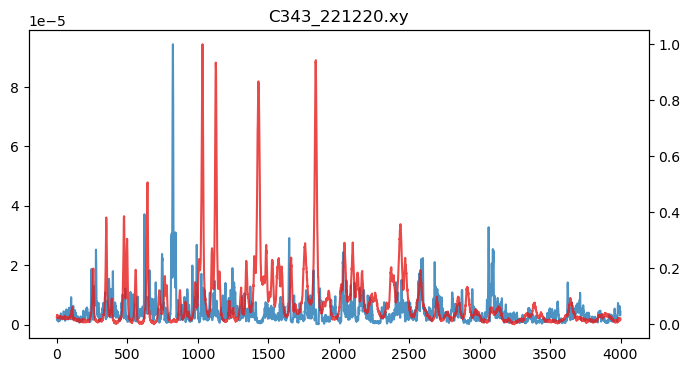

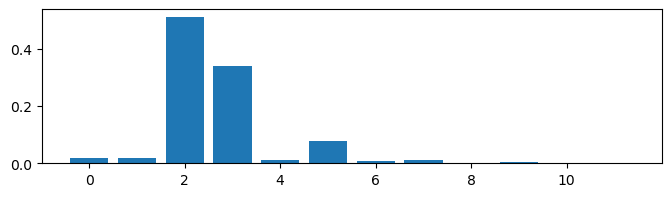

In [155]:
def saliency_experimental_data(model, experimental_data, input_size):
    saliencies = []
    total_difference = 0.0
    exp_samples_nb = 0

    diff_by_phases = []
    for i in range(num_phases):
        diff_by_phases.append(0)

    for filename, intensities in experimental_data.items():

        #print(intensities.shape)
        interpolated_intensities = torch.tensor(intensities, dtype=torch.float32).unsqueeze(0).unsqueeze(0).to(device)[:,:,1:]
        #print(interpolated_intensities)
        interpolated_intensities.requires_grad = True
        #model.eval()
        #with torch.no_grad():
        model.zero_grad()
        #predicted_weights = model(interpolated_intensities)

        # Умножаем предсказанные веса на 100
        #predicted_weights *= 100    
        if filename in target_values:
            target = target_values[filename]*0.01
            target = torch.tensor(target.reshape(1,12), dtype=torch.float32).to(device)
    
            predicted_weights = model(interpolated_intensities)        
            
            #print(target.shape)
            #print(predicted_weights.shape)
            
            loss = criterion(predicted_weights, target)
            loss.mean().backward()
    
            saliency = interpolated_intensities.grad.data.abs()
            saliency = saliency.squeeze().cpu().numpy()
            saliency2 = np.copy(saliency)
            for i in range(len(saliency)):
                saliency2[i] = np.mean(saliency[i-2:i+2])
            #print(saliency)
            #plt.plot(saliency)
            #plt.show()
    
            #break
            
            saliencies.append((filename, saliency2))

        # Сравнение с целевыми значениями, если они есть
        if filename in target_values:
            target = target_values[filename]
            curr_phases = np.square(predicted_weights.detach().squeeze().cpu().numpy() - target*0.01)
            total_difference += curr_phases.sum()
            diff_by_phases += curr_phases  # Аккумулируем разности для каждой фазы
            exp_samples_nb += 1
        #break

    if exp_samples_nb > 0:
        total_difference = (total_difference / exp_samples_nb) / num_phases
        diff_by_phases /= exp_samples_nb  # Вычисляем средние значения для каждой фазы
    else:
        total_difference = 0.0
        diff_by_phases = np.zeros(num_phases)

    return total_difference, diff_by_phases, exp_samples_nb, saliencies

    
total_exp_diff, ph_exp_diff, exp_samples_nb, saliencies = saliency_experimental_data(model, experimental_data, input_size)
for filename, saliency in saliencies:
    fig, ax = plt.subplots(figsize=(8,4))
    ax.plot(saliency,alpha=0.8)
    ax2 = ax.twinx()
    ax2.plot(experimental_data[filename][1:],c=(0.9,0.1,0.1),alpha=0.8)
    ax.set_title(f'{filename}')    
    plt.show()
    fig, ax = plt.subplots(figsize=(8,2))
    plt.bar(np.arange(0,12),target_values[filename]*0.01)
    plt.show()
    break